In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s6e1/sample_submission.csv
/kaggle/input/playground-series-s6e1/train.csv
/kaggle/input/playground-series-s6e1/test.csv
/kaggle/input/exam-score-prediction-dataset/Exam_Score_Prediction.csv


In [2]:
class CONFIG:
    INPUT_DIR = '/kaggle/input/playground-series-s6e1'

    SEED = 42
    FOLDS = 5
    TARGET = 'exam_score'

config = CONFIG()

In [3]:
train = pd.read_csv(f'{config.INPUT_DIR}/train.csv')
test = pd.read_csv(f'{config.INPUT_DIR}/test.csv')

train_org = pd.read_csv('/kaggle/input/exam-score-prediction-dataset/Exam_Score_Prediction.csv')
submission = pd.read_csv(f'{config.INPUT_DIR}/sample_submission.csv')

train['source'] = 'train'
test['source'] = 'test'
train_org['source'] = 'original'

cols = train.columns
cols = [col for col in cols if col not in ['id', 'student_id']]

test[config.TARGET] = np.nan

train = train[cols].copy()
test = test[cols].copy()
train_org = train_org[cols].copy()

combine = pd.concat([train_org, train, test], axis=0, ignore_index=True)


<Axes: xlabel='exam_score', ylabel='Count'>

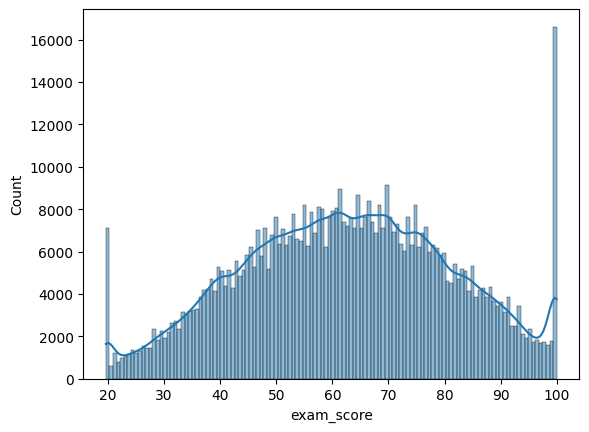

In [4]:
import seaborn as sns
sns.histplot(train[config.TARGET], kde=True)

In [5]:
FEATURES = [col for col in cols if col not in [config.TARGET, 'source']]
CATS = combine[FEATURES].select_dtypes(include='object').columns.to_list()
CATS = [col for col in CATS if col not in ['source']]
NUMS = combine[FEATURES].select_dtypes(include=['int64', 'float64']).columns.to_list()

for df in [combine]:
    for col in NUMS:
        if df[col].dtype=='int64':
            df[col] = df[col].astype('int32')
        else:
            df[col] = df[col].astype('float32')

combine[CATS] = combine[CATS].astype('category')

In [6]:
CATS1 = []

for c in NUMS:
    n = f'{c}_cat'
    for df in [combine]:
        df[n] = df[c].astype('category')
        print(df[n].dtype)

    CATS1.append(n)

for c in CATS1:
    combine[c] = combine[c].cat.codes.astype('int32')  
    combine[c] = combine[c].astype('category')         
print(CATS1)

category
category
category
category
['age_cat', 'study_hours_cat', 'class_attendance_cat', 'sleep_hours_cat']


In [7]:
CATS2 = []
SIZES = {}

for c in CATS+CATS1:
    n = f'{c}_enc'
    for df in [combine]:
        # df[c] = df[c].astype('category')
        df[n], _ = df[c].factorize()
        df[n] = df[n].astype('int32')
        s = df[n].max()+1

    CATS2.append(n)
    SIZES[n] = s

print(CATS2)
print('='*30)
print(SIZES)

['gender_enc', 'course_enc', 'internet_access_enc', 'sleep_quality_enc', 'study_method_enc', 'facility_rating_enc', 'exam_difficulty_enc', 'age_cat_enc', 'study_hours_cat_enc', 'class_attendance_cat_enc', 'sleep_hours_cat_enc']
{'gender_enc': 3, 'course_enc': 7, 'internet_access_enc': 2, 'sleep_quality_enc': 3, 'study_method_enc': 5, 'facility_rating_enc': 3, 'exam_difficulty_enc': 3, 'age_cat_enc': 8, 'study_hours_cat_enc': 794, 'class_attendance_cat_enc': 631, 'sleep_hours_cat_enc': 70}


In [8]:
# ROUND = []
# rounding_levels = {'1s':0, '10s':-1}

# for c in ['study_hours', 'class_attendance', 'sleep_hours']:
#     for suffix, level in rounding_levels.items():
#         n = f'{c}_ROUND_{suffix}'
#         ROUND.append(n)
#         for df in [combine]:
#             df[n] = df[c].round(level).astype('int32')

# print(len(ROUND))

In [9]:
train_idx = combine['source'] == 'train'
test_idx = combine['source'] == 'test'
train_org_idx = combine['source'] == 'original'

train_n = combine[train_idx].reset_index(drop=True).copy()
test_n = combine[test_idx].reset_index(drop=True).copy()
train_org_n = combine[train_org_idx].reset_index(drop=True).copy()

In [10]:
BINS = []
q_list = [10, 20, 30]

for col in NUMS:
    for q in q_list:
        n = f'{col}_bin{q}'

        _, bins = pd.qcut(
            train_org_n[col], q=q, retbins=True, labels=False,
            duplicates='drop'
        )

        train_org_n[n] = pd.cut(train_org_n[col], bins=bins, labels=False, include_lowest=True).astype(np.int8)
        train_n[n] = pd.cut(train_n[col], bins=bins, labels=False, include_lowest=True).astype(np.int8)
        test_n[n] = pd.cut(test_n[col], bins=bins, labels=False, include_lowest=True).astype(np.int8)

        BINS.append(n)

print(f"{len(BINS)} k-bins discretization features created")

12 k-bins discretization features created


In [11]:
TE = []

for c in CATS+CATS1+BINS:
    tmp_mean = train_org_n.groupby(c)[config.TARGET].mean()
    tmp_median = train_org_n.groupby(c)[config.TARGET].median()
    tmp_std = train_org_n.groupby(c)[config.TARGET].std()
    # tmp_count = train_org_n.groupby(c)[config.TARGET].size()

    n_mean = f'TE_{c}_mean'
    n_median = f'TE_{c}_median'
    n_std = f'TE_{c}_std'
    # n_c = f'TE_{c}_count'
    print(f'{n_mean}, {n_median}, {n_std}, ', end=' ')
    tmp_mean.name = n_mean
    tmp_median.name = n_median
    tmp_std.name = n_std
    
    stats = (pd.concat([tmp_mean, tmp_median, tmp_std], axis=1).reset_index().rename(columns={'index': c}))
    train_org_n = train_org_n.merge(stats, on=c, how='left')
    train_n = train_n.merge(stats, on=c, how='left')
    test_n = test_n.merge(stats, on=c, how='left')

    TE.append(n_mean)
    # TE.append(n_median)
    TE.append(n_std)
    # TE.append(n_c)

print('\n',)
print(len(TE))

TE_gender_mean, TE_gender_median, TE_gender_std,  TE_course_mean, TE_course_median, TE_course_std,  TE_internet_access_mean, TE_internet_access_median, TE_internet_access_std,  TE_sleep_quality_mean, TE_sleep_quality_median, TE_sleep_quality_std,  TE_study_method_mean, TE_study_method_median, TE_study_method_std,  TE_facility_rating_mean, TE_facility_rating_median, TE_facility_rating_std,  TE_exam_difficulty_mean, TE_exam_difficulty_median, TE_exam_difficulty_std,  TE_age_cat_mean, TE_age_cat_median, TE_age_cat_std,  TE_study_hours_cat_mean, TE_study_hours_cat_median, TE_study_hours_cat_std,  TE_class_attendance_cat_mean, TE_class_attendance_cat_median, TE_class_attendance_cat_std,  TE_sleep_hours_cat_mean, TE_sleep_hours_cat_median, TE_sleep_hours_cat_std,  TE_age_bin10_mean, TE_age_bin10_median, TE_age_bin10_std,  TE_age_bin20_mean, TE_age_bin20_median, TE_age_bin20_std,  TE_age_bin30_mean, TE_age_bin30_median, TE_age_bin30_std,  TE_study_hours_bin10_mean, TE_study_hours_bin10_median

In [12]:
from sklearn.base import BaseEstimator, TransformerMixin

class TargetEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=True):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        temp_df = X.copy()
        temp_df['target'] = y

        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping

        return self

    def transform(self, X):
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f'TE_{col}_{agg_func}'
                map_series = self.mappings_[col][agg_func]
    
                # 1. map, 2. cast to float, 3. fill NaN
                X_transformed[new_col_name] = (
                    X[col].map(map_series)
                         .astype(float)          # <-- key line
                         .fillna(self.global_stats_[agg_func])
                )
    
        if self.drop_original:                   # typo fixed
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)
    
        return X_transformed

    def fit_transform(self, X, y):

        self.fit(X, y)
        encoded_features = pd.DataFrame(index=X.index)

        skf = StratifiedKFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in skf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[val_idx]
            X_val = X.iloc[val_idx]

            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}'

                    fold_global_stats = y_train.agg(agg_func)
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()

                        m = self.smooth
                        if self.smooth == 'auto':
                            variance_between = mapping .var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between

                            else:
                                m = 0

                        smoothed_mapping = (counts * mapping + m * fold_global_stats) / (counts + m)

                        encoded_values = X_val[col].map(smoothed_mapping)

                    else:
                        encoded_values = X_val[col].map(mapping)

                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stats)

            X_transformed = X.copy()
            for col in encoded_features.columns:
                X_transformed[col] = encoded_features[col]

            if self.drop_original:
                X_transformed.drop(columns=self.cols_to_encode, inplace=True)

            return X_transformed
                    

In [13]:
FEATURES_N = CATS + CATS1 + CATS2 + NUMS + TE 
len(FEATURES_N)

X = train_n[FEATURES_N].copy()
y = train_n[config.TARGET].copy()

X_org = train_org_n[FEATURES_N].copy()
y_org = train_org_n[config.TARGET].copy()

test_n = test_n[FEATURES_N].copy()

def rmse(y, y_val):
    y_array = np.array(y)
    y_val_array = np.array(y_val)
    mse = np.mean((y_array - y_val_array)**2)
    rmse = np.sqrt(mse)
    return rmse

In [14]:
from xgboost import XGBRegressor
from sklearn.model_selection import KFold
import gc
import warnings
warnings.filterwarnings('ignore')

params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'max_depth': 5,
    'colsample_bytree': 0.5,
    'subsample': 0.8,
    'n_estimators': 10000,
    'learning_rate': 0.01,
    'early_stopping_rounds': 100,
    'random_state': 42,
    'n_jobs': -1,
    'device': 'cuda',
    'enable_categorical': True,
}

kf = KFold(n_splits=config.FOLDS, shuffle=True, random_state=config.SEED)

oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(test_n))


fold_scores = []
for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    X_org_n = X_org.copy()
    y_org_n = y_org.copy()
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
    print(f'TRAINING SHAPE BEFORE DUPLICATION: {X_train.shape}')
    # for i in range(1):
    #     X_train = pd.concat([X_train, X_train], axis=0)
    #     y_train = pd.concat([y_train, y_train], axis=0)

    # for j in range(2):
    #     X_org_n = pd.concat([X_org_n, X_org_n], axis=0)
    #     y_org_n = pd.concat([y_org_n, y_org_n], axis=0)
    # print(f'TRAINING SHAPE AFTER DUPLICATION: {X_train.shape}')
    X_train = pd.concat([X_org_n, X_train], axis=0, ignore_index=True)
    y_train = pd.concat([y_org_n, y_train], axis=0, ignore_index=True)
    # print(f'TRAINING SHAPE :{X_train.shape}')
    # print(f'VALIDATION SHAPE :{X_val.shape}')
    
    # X_val = pd.concat([X_val])
    # print(f'TRAINING SHAPE BEFORE ENCODING :{X_train.shape}')
    # TE = TargetEncoder(cols_to_encode=CATS, aggs=['mean', 'count'], cv=5, smooth='auto', drop_original=False)
    # X_train = TE.fit_transform(X_train, y_train)
    # X_val = TE.transform(X_val)
    # test_enc = TE.transform(test_n)

    # TE2 = TargetEncoder(cols_to_encode=ROUND, aggs=['mean', 'count'], cv=5, smooth='auto', drop_original=True)
    # X_train = TE2.fit_transform(X_train, y_train)
    # X_val = TE2.transform(X_val)
    # test_enc = TE2.transform(test_n)
    # print(f'TRAINING SHAPE AFTER ENCODING :{X_train.shape}')
    model = XGBRegressor(**params)

    model.fit(X_train, y_train,
             eval_set=[(X_val, y_val)],
             verbose=1000)

    val_preds = model.predict(X_val)
    # oof_preds[val_idx] = val_preds

    fold_score = rmse(y_val, val_preds)
    fold_scores.append(fold_score)
    print(f'FOLD {fold} AUC: {fold_score:.4f}')
    test_preds +=  model.predict(test_n) / config.FOLDS


overall_rmse = np.mean(fold_scores)

print('='*30)
print(f"Overall OOF AUC: {overall_rmse:.4f}")
print('='*30)

TRAINING SHAPE BEFORE DUPLICATION: (504000, 72)
[0]	validation_0-rmse:18.73162
[1000]	validation_0-rmse:8.66466
[2000]	validation_0-rmse:8.65416
[2673]	validation_0-rmse:8.65223
FOLD 0 AUC: 8.6521
TRAINING SHAPE BEFORE DUPLICATION: (504000, 72)
[0]	validation_0-rmse:18.77541
[1000]	validation_0-rmse:8.66995
[2000]	validation_0-rmse:8.65889
[3000]	validation_0-rmse:8.65483
[3848]	validation_0-rmse:8.65376
FOLD 1 AUC: 8.6538
TRAINING SHAPE BEFORE DUPLICATION: (504000, 72)
[0]	validation_0-rmse:18.78085
[1000]	validation_0-rmse:8.66148
[2000]	validation_0-rmse:8.64939
[2993]	validation_0-rmse:8.64622
FOLD 2 AUC: 8.6462
TRAINING SHAPE BEFORE DUPLICATION: (504000, 72)
[0]	validation_0-rmse:18.84078
[1000]	validation_0-rmse:8.66944
[2000]	validation_0-rmse:8.65628
[3000]	validation_0-rmse:8.65235
[3161]	validation_0-rmse:8.65229
FOLD 3 AUC: 8.6521
TRAINING SHAPE BEFORE DUPLICATION: (504000, 72)
[0]	validation_0-rmse:18.81724
[1000]	validation_0-rmse:8.68820
[2000]	validation_0-rmse:8.67463
[

In [15]:
submission[config.TARGET] = test_preds
submission.to_csv(f'submission_{overall_rmse}.csv', index=False)

In [16]:
imp_n = pd.DataFrame(
    {
        'feature_names': model.feature_names_in_,
        'gain': model.feature_importances_
    }
).sort_values('gain', ascending=False).reset_index(drop=True)

imp_n.to_csv('xgb_feature_importance.csv', index=False)
imp_n.head(10)

,feature_names,gain
0,TE_study_hours_cat_mean,0.209539
1,TE_study_hours_bin20_mean,0.157365
2,TE_study_hours_bin30_mean,0.130258
3,study_hours,0.099258
4,TE_study_hours_bin10_mean,0.083634
5,TE_study_hours_bin10_std,0.032457
6,TE_class_attendance_bin30_mean,0.029867
7,TE_class_attendance_bin20_mean,0.024861
8,class_attendance,0.024053
9,TE_class_attendance_bin10_mean,0.018463
